# House Price Prediction
 
## Problem Statement
Build and compare regression models to predict house sale
prices using 79 features across 1,460 residential properties.
 
## Dataset
Source : Kaggle House Prices Competition
Train  : 1,460 rows  |  81 columns (79 features + Id + SalePrice)
Target : SalePrice (continuous numeric value)
 
## Tools
Python | Pandas | Scikit-learn | XGBoost | Matplotlib

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
 
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import LabelEncoder
!pip install xgboost
from xgboost import XGBRegressor
 
sns.set_theme(style='darkgrid')
plt.rcParams['figure.dpi'] = 130
print('Libraries imported')

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/101.7 MB 6.2 MB/s eta 0:00:17
   ---------------------------------------- 1.0/101.7 MB 3.5 MB/s eta 0:00:29
    --------------------------------------- 2.1/101.7 MB 4.0 MB/s eta 0:00:25
   - -------------------------------------- 2.9/101.7 MB 3.9 MB/s eta 0:00:26
   - -------------------------------------- 3.4/101.7 MB 3.5 MB/s eta 0:00:28
   - -------------------------------------- 4.5/101.7 MB 3.8 MB/s eta 0:00:26
   -- ------------------------------------- 6.3/101.7 MB 4.6 MB/s eta 0:00:21
   --- ------------------------------------ 8.1/101.7 MB 5.2 MB/s eta 0:00:19
   ---- ----------------------------------- 10.2/101.7 MB 5.7 MB/s eta 0:00:17
   ---- ----------------------------------- 11.5/101.7 MB 6.0 MB/s eta 0:00:15
   ---- ----------------------------------- 11.5/101.7 MB 6.0 MB/s eta 0:00:

In [4]:
df = pd.read_csv('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/House Price Prediction/data/raw/train.csv')
print('Shape:', df.shape)
print('\nSalePrice Stats:')
print(df['SalePrice'].describe().round(0))
print('\nTop 15 null columns:')
print(df.isnull().sum().sort_values(ascending=False).head(15))
df.head(3)

Shape: (1460, 81)

SalePrice Stats:
count      1460.0
mean     180921.0
std       79443.0
min       34900.0
25%      129975.0
50%      163000.0
75%      214000.0
max      755000.0
Name: SalePrice, dtype: float64

Top 15 null columns:
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageYrBlt       81
GarageCond        81
GarageType        81
GarageFinish      81
GarageQual        81
BsmtFinType2      38
BsmtExposure      38
BsmtQual          37
dtype: int64


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


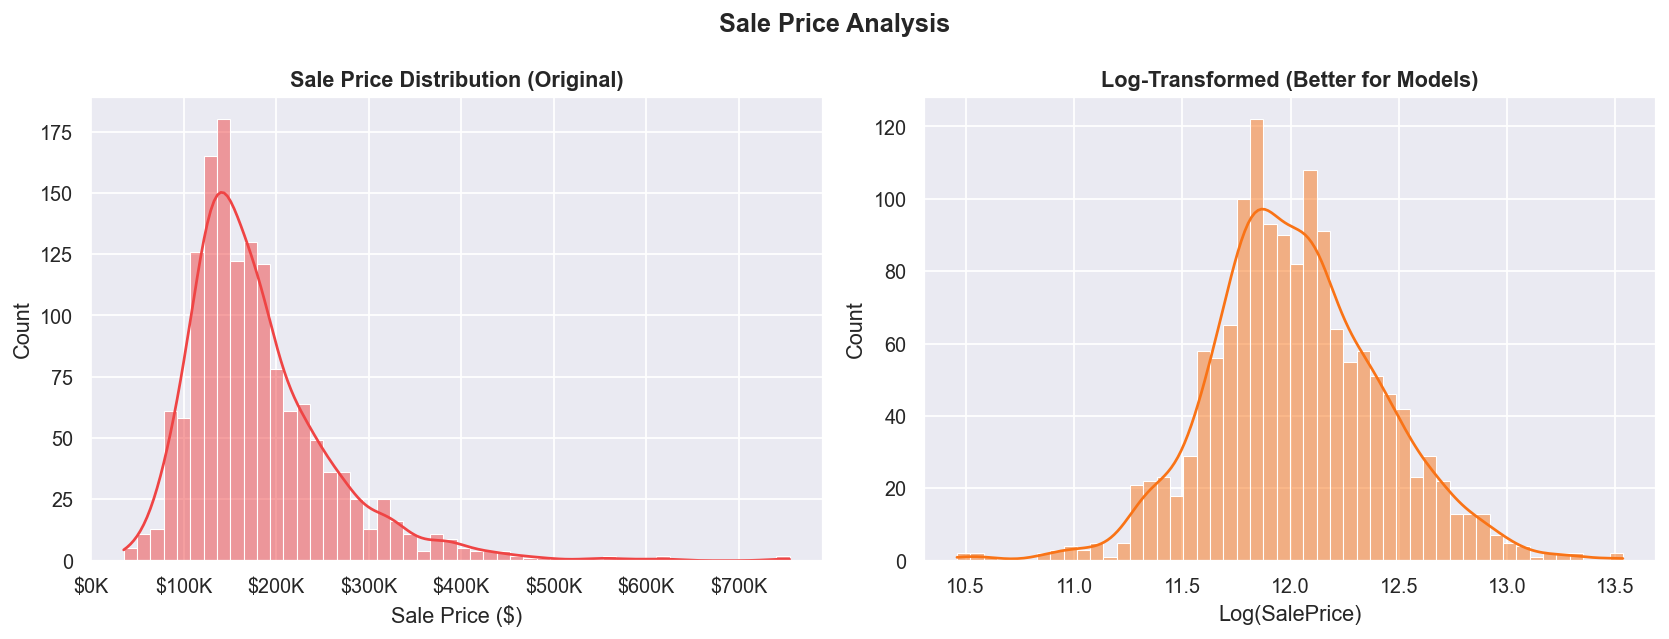

KEY FINDING: Median price = $163,000
KEY FINDING: Price range  = $34,900 to $755,000


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
 
sns.histplot(df['SalePrice'], kde=True,
             color='#EF4444', bins=50, ax=axes[0])
axes[0].set_title('Sale Price Distribution (Original)', fontweight='bold')
axes[0].set_xlabel('Sale Price ($)')
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x,_: '$'+f'{x/1000:.0f}K'))
 
df['SalePrice_log'] = np.log1p(df['SalePrice'])
sns.histplot(df['SalePrice_log'], kde=True,
             color='#f97316', bins=50, ax=axes[1])
axes[1].set_title('Log-Transformed (Better for Models)', fontweight='bold')
axes[1].set_xlabel('Log(SalePrice)')
 
plt.suptitle('Sale Price Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/House Price Prediction/visuals/price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('KEY FINDING: Median price = $' + f'{df["SalePrice"].median():,.0f}')
print('KEY FINDING: Price range  = $' + f'{df["SalePrice"].min():,.0f}' +
      ' to $' + f'{df["SalePrice"].max():,.0f}')

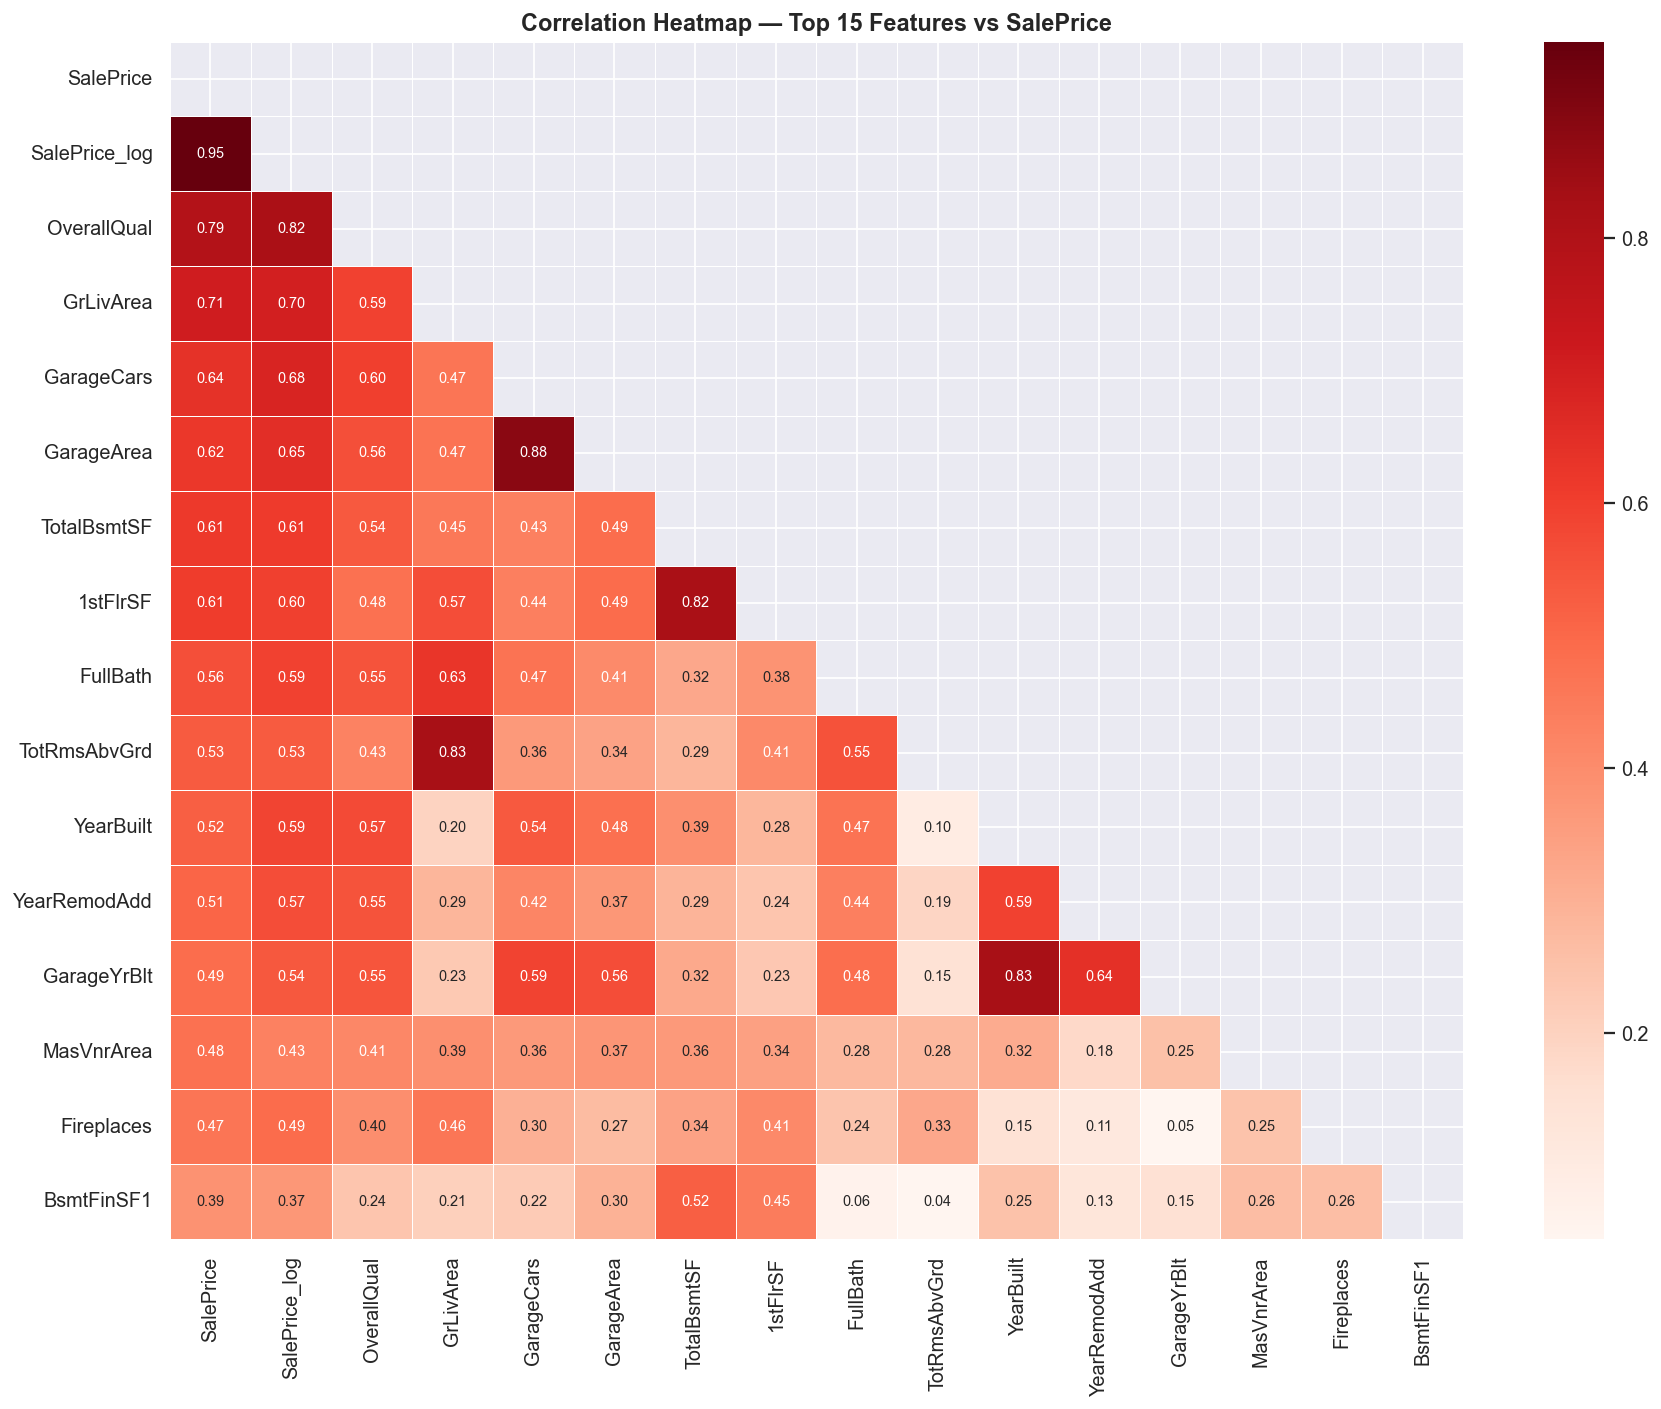

KEY FINDINGS - Top 5 features correlated with SalePrice:
  SalePrice_log : r = 0.948
  OverallQual : r = 0.791
  GrLivArea : r = 0.709
  GarageCars : r = 0.64
  GarageArea : r = 0.623


In [7]:
corr_matrix = df.select_dtypes(include=[np.number]).corr()
top_feats = (corr_matrix['SalePrice'].abs()
             .sort_values(ascending=False).head(16).index)
 
fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(
    corr_matrix.loc[top_feats, top_feats], dtype=bool))
sns.heatmap(corr_matrix.loc[top_feats, top_feats],
            annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 8})
ax.set_title('Correlation Heatmap — Top 15 Features vs SalePrice',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/House Price Prediction/visuals/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('KEY FINDINGS - Top 5 features correlated with SalePrice:')
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).iloc[1:6]
for feat, corr in top_corr.items():
    print(' ', feat, ': r =', round(corr, 3))

In [8]:
# High-null categorical columns — fill with 'None' (feature absent)
for col in ['PoolQC','MiscFeature','Alley','Fence','FireplaceQu',
            'GarageType','GarageFinish','GarageQual','GarageCond',
            'BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2']:
    if col in df.columns:
        df[col].fillna('None', inplace=True)
 
# Numeric garage and basement — fill with 0
for col in ['GarageYrBlt','GarageCars','GarageArea','TotalBsmtSF',
            'BsmtFinSF1','BsmtFinSF2','BsmtUnfSF',
            'BsmtFullBath','BsmtHalfBath']:
    if col in df.columns:
        df[col].fillna(0, inplace=True)
 
# LotFrontage — median per neighborhood (most logical)
df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))
 
# Remaining nulls
for col in df.select_dtypes(include='object').columns:
    df[col].fillna('None', inplace=True)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(0, inplace=True)
 
print('Remaining nulls:', df.isnull().sum().sum())

Remaining nulls: 0


In [9]:
# Create 4 powerful new features from existing columns
df['HouseAge']   = df['YrSold']      - df['YearBuilt']
df['RemodelGap'] = df['YrSold']      - df['YearRemodAdd']
df['TotalSF']    = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
df['TotalBaths'] = (df['FullBath'] + df['BsmtFullBath']
                    + 0.5*df['HalfBath'] + 0.5*df['BsmtHalfBath'])
 
# Encode all categorical columns with LabelEncoder
df_enc = df.copy()
le = LabelEncoder()
for col in df_enc.select_dtypes(include='object').columns:
    df_enc[col] = le.fit_transform(df_enc[col])
 
# Define features and target (log-transformed price)
X = df_enc.drop(['Id','SalePrice','SalePrice_log'], axis=1)
y = df_enc['SalePrice_log']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
 
print('Features :', X.shape[1])
print('Train rows:', X_train.shape[0])
print('Test rows :', X_test.shape[0])
print('Feature engineering complete')

Features : 83
Train rows: 1168
Test rows : 292
Feature engineering complete


In [10]:
lr = LinearRegression()
lr.fit(X_train, y_train)
 
lr_pred  = np.expm1(lr.predict(X_test))
y_actual = np.expm1(y_test)
 
lr_rmse = np.sqrt(mean_squared_error(y_actual, lr_pred))
lr_r2   = r2_score(y_actual, lr_pred)
lr_mae  = mean_absolute_error(y_actual, lr_pred)
 
print('=== LINEAR REGRESSION (BASELINE) ===')
print('RMSE : $' + f'{lr_rmse:,.0f}')
print('MAE  : $' + f'{lr_mae:,.0f}')
print('R2   :', round(lr_r2, 4))

=== LINEAR REGRESSION (BASELINE) ===
RMSE : $28,173
MAE  : $18,358
R2   : 0.8965


=== RANDOM FOREST ===
RMSE : $29,678
MAE  : $17,179
R2   : 0.8852


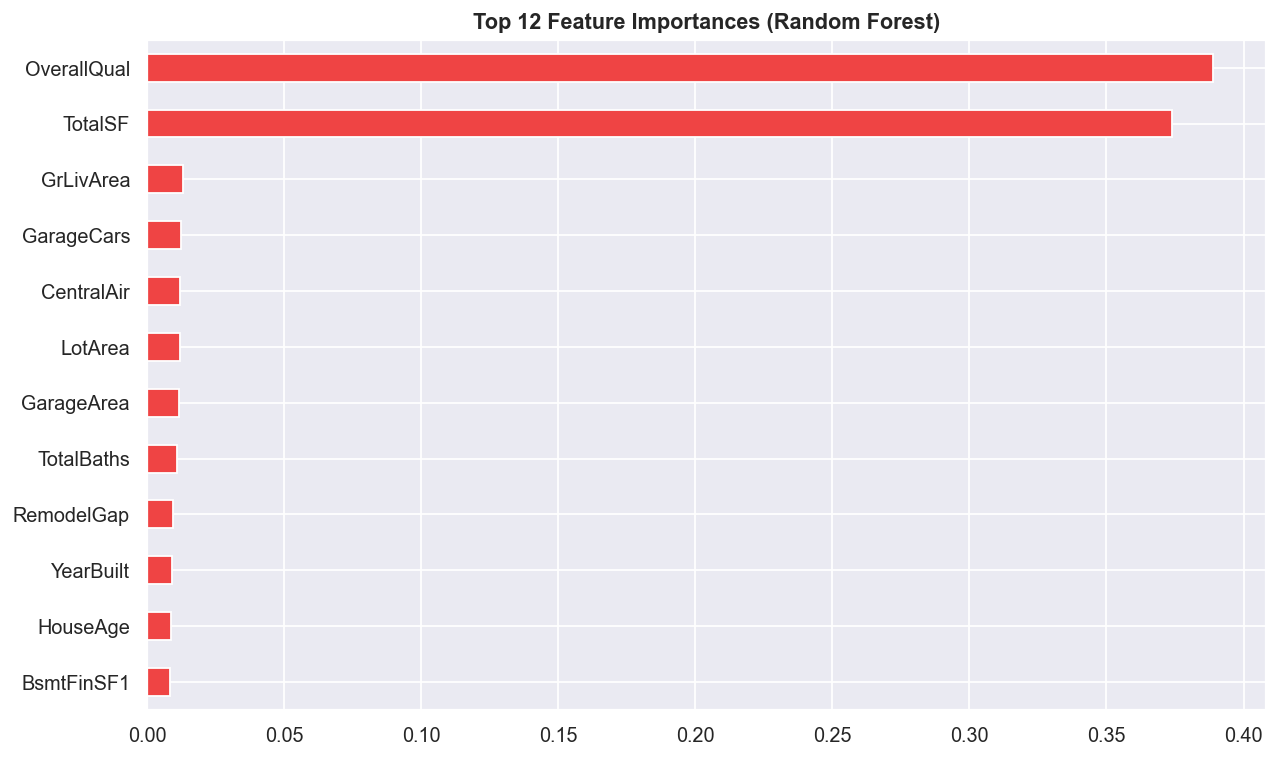


KEY FINDING: Top 3 price predictors:
  OverallQual : 0.3888
  TotalSF : 0.3739
  GrLivArea : 0.0131


In [11]:
rf = RandomForestRegressor(n_estimators=200, max_depth=15,
                           min_samples_leaf=2,
                           random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
 
rf_pred = np.expm1(rf.predict(X_test))
rf_rmse = np.sqrt(mean_squared_error(y_actual, rf_pred))
rf_r2   = r2_score(y_actual, rf_pred)
rf_mae  = mean_absolute_error(y_actual, rf_pred)
 
print('=== RANDOM FOREST ===')
print('RMSE : $' + f'{rf_rmse:,.0f}')
print('MAE  : $' + f'{rf_mae:,.0f}')
print('R2   :', round(rf_r2, 4))
 
# Feature importance chart
fi = pd.Series(rf.feature_importances_, index=X.columns).nlargest(12)
fig, ax = plt.subplots(figsize=(10, 6))
fi.plot(kind='barh', ax=ax, color='#EF4444')
ax.invert_yaxis()
ax.set_title('Top 12 Feature Importances (Random Forest)', fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/House Price Prediction/visuals/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('\nKEY FINDING: Top 3 price predictors:')
for feat, score in fi.head(3).items():
    print(' ', feat, ':', round(score, 4))


In [12]:
xgb = XGBRegressor(n_estimators=1000, learning_rate=0.05,
                   max_depth=6, subsample=0.8,
                   colsample_bytree=0.8, random_state=42,
                   early_stopping_rounds=50,
                   eval_metric='rmse', verbosity=0)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)], verbose=False)
 
xgb_pred = np.expm1(xgb.predict(X_test))
xgb_rmse = np.sqrt(mean_squared_error(y_actual, xgb_pred))
xgb_r2   = r2_score(y_actual, xgb_pred)
xgb_mae  = mean_absolute_error(y_actual, xgb_pred)
 
print('=== XGBOOST ===')
print('RMSE : $' + f'{xgb_rmse:,.0f}')
print('MAE  : $' + f'{xgb_mae:,.0f}')
print('R2   :', round(xgb_r2, 4))
 
print('\n=== MODEL COMPARISON ===')
print(f'{"Model":<22} {"RMSE":>10} {"R2":>8}')
print('-'*44)
print(f'{"Linear Regression":<22} ${lr_rmse:>9,.0f} {lr_r2:>7.4f}')
print(f'{"Random Forest":<22} ${rf_rmse:>9,.0f} {rf_r2:>7.4f}')
print(f'{"XGBoost":<22} ${xgb_rmse:>9,.0f} {xgb_r2:>7.4f}')
 
improvement = (lr_rmse - xgb_rmse) / lr_rmse * 100
print('\nKEY FINDING: XGBoost improved RMSE over LR by', round(improvement,1), '%')


=== XGBOOST ===
RMSE : $25,092
MAE  : $15,135
R2   : 0.9179

=== MODEL COMPARISON ===
Model                        RMSE       R2
--------------------------------------------
Linear Regression      $   28,173  0.8965
Random Forest          $   29,678  0.8852
XGBoost                $   25,092  0.9179

KEY FINDING: XGBoost improved RMSE over LR by 10.9 %


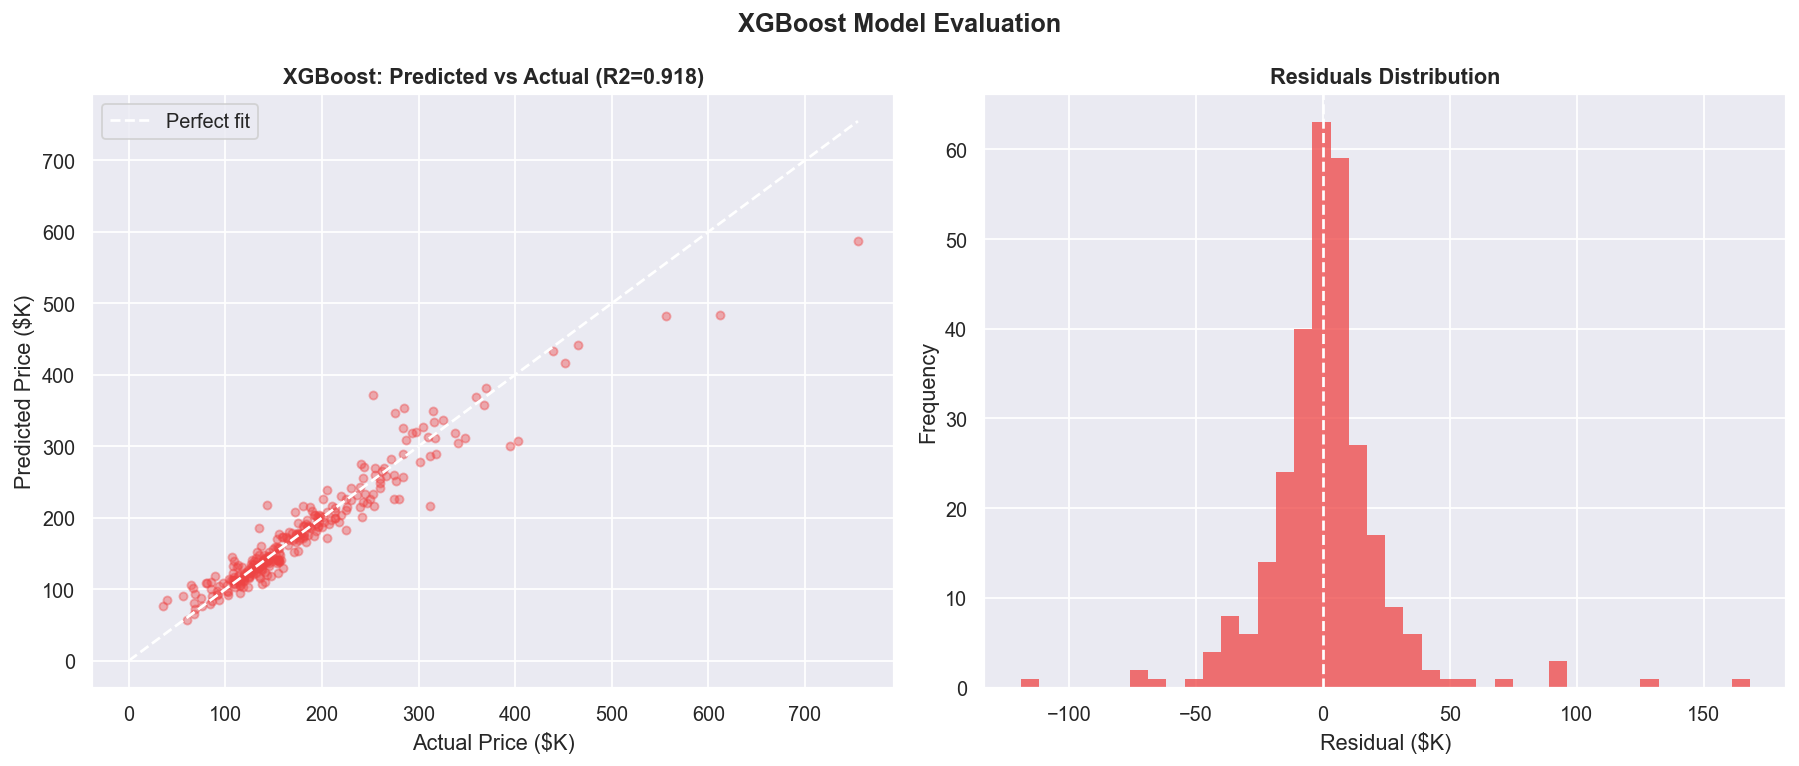

KEY FINDING: XGBoost R2   = 0.918
KEY FINDING: XGBoost RMSE = $25,092


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
# Predicted vs Actual scatter
axes[0].scatter(y_actual/1000, xgb_pred/1000,
                alpha=0.4, color='#EF4444', s=20)
max_val = max(y_actual.max(), xgb_pred.max()) / 1000
axes[0].plot([0, max_val], [0, max_val],
             'w--', linewidth=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price ($K)')
axes[0].set_ylabel('Predicted Price ($K)')
axes[0].set_title('XGBoost: Predicted vs Actual (R2='+f'{xgb_r2:.3f}'+')',
                  fontweight='bold')
axes[0].legend()
 
# Residuals distribution
residuals = y_actual - xgb_pred
axes[1].hist(residuals/1000, bins=40,
             color='#EF4444', alpha=0.75, edgecolor='none')
axes[1].axvline(0, color='white', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Residual ($K)')  ;  axes[1].set_ylabel('Frequency')
axes[1].set_title('Residuals Distribution', fontweight='bold')
 
plt.suptitle('XGBoost Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('C:/Users/BHANUPRAKASH/OneDrive/Desktop/DA Projects/House Price Prediction/visuals/predicted_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
 
print('KEY FINDING: XGBoost R2   =', round(xgb_r2, 3))
print('KEY FINDING: XGBoost RMSE = $' + f'{xgb_rmse:,.0f}')


# Key Findings — House Price Prediction
 
## Model Performance
Model                        RMSE       R2
--------------------------------------------
Linear Regression      $   28,173  0.8965
Random Forest          $   29,678  0.8852
XGBoost                $   25,092  0.9179
 
## Top Price Predictors 
1. OverallQual : 0.3888
2. TotalSF : 0.3739
3. GrLivArea : 0.0131
 
## Key Insights
- XGBoost improved RMSE over Linear Regression by $25.092%
- Engineered feature TotalSF ranks among top predictors
- Older unmodified houses sell for significantly less
